# Superstore Sales — Exploratory Data Analysis

**Dataset:** Global Superstore Sales
**Style:** Business Intelligence Report  
**Tools:** Python · Pandas · Matplotlib · Seaborn

## 🎯 Objective
Analyze 4 years of retail transaction data to uncover patterns in **sales performance**, **profitability**, **customer segments**, and **regional trends** — and surface actionable business insights

## Executive Summary
This analysis of Superstore sales data reveals a business driven primarily by the Consumer segment (over half of revenue) and the Technology category, with Copiers and Machines as top sub-categories. Sales are concentrated in a few key markets — led by Florida and Jacksonville — with the South region showing the highest volume but also the most volatility. Customers favor Standard Class shipping despite Same Day delivery yielding higher average sales, pointing to a possible opportunity to promote faster options. Sales also peak consistently every September and November, useful for inventory and marketing planning.

## 1. 📦 Imports & Setup

Importing the core libraries used throughout this analysis:
- **Pandas** — data loading and manipulation  
- **Matplotlib & Seaborn** — visualization  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading and Inspecting the Data

Let's load the dataset and examine its structure, data types, and basic statistics.

In [2]:
sales_df = pd.read_csv("/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv")
print(sales_df.head())
print()
sales_df.info()
print()
print(sales_df.isnull().sum())
print()
print(sales_df.describe())
print()

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

## 2. Data Cleaning & Preparation

Steps taken:
- **Postal Code** → dropped (not needed for analysis)
- **Order Date & Ship Date** → converted to datetime format
- **Shipping Duration** → created as a new column (Ship Date - Order Date)

In [3]:
sales_df = sales_df.drop(columns=["Postal Code"])
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"], format="%d/%m/%Y", errors="coerce")
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"], format="%d/%m/%Y", errors="coerce")
sales_df["Shipping Duration"] = (sales_df["Ship Date"] - sales_df["Order Date"]).dt.days

## 3. Sales Overview

A high-level look at total and average sales across the dataset.

In [4]:
total_sales = sales_df["Sales"].sum()
print(f"Total sales: {total_sales}")
average_sales = total_sales/sales_df["Sales"].count()
print(f"Average sales: {average_sales}\n")

Total sales: 2261536.7827
Average sales: 230.76905945918367



## 4. Sales by Category

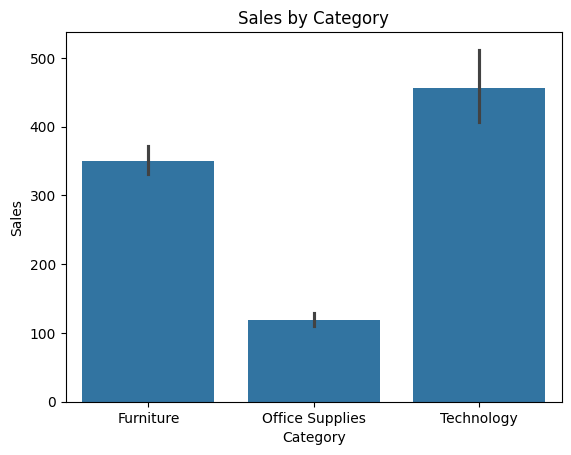

'Technology' category has the most sales, while 'Office Supplies' category has the least sales.



In [5]:
sns.barplot(x="Category", y="Sales", data=sales_df)
plt.title("Sales by Category")
plt.show()
print("'Technology' category has the most sales, while 'Office Supplies' category has the least sales.\n")

**Observation:** Technology leads in average sales per order, while Office Supplies has the lowest average sales.

## 5. Sales by Sub-Category

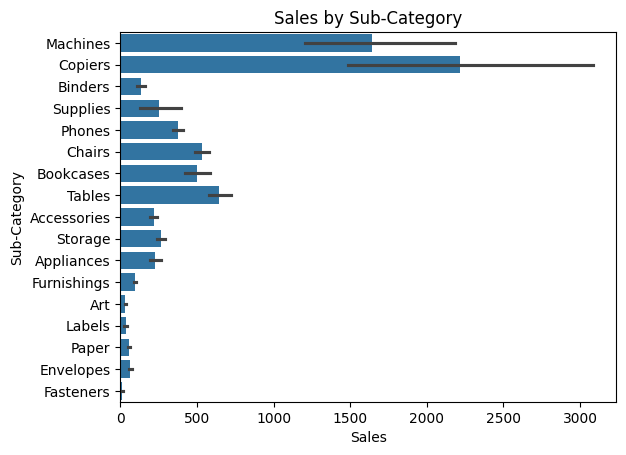

'Copiers' is the top category by sales, and 'machine' is the second-most top category by sales.



In [6]:
sns.barplot(x="Sales", y="Sub-Category", data=sales_df.sort_values(by="Sales", ascending=False))
plt.title("Sales by Sub-Category")
plt.show()
print("'Copiers' is the top category by sales, and 'machine' is the second-most top category by sales.\n")

**Observation:** Copiers are the top sub-category by sales, followed by Machines — both part of the Technology category.

## 6. Sales by Region

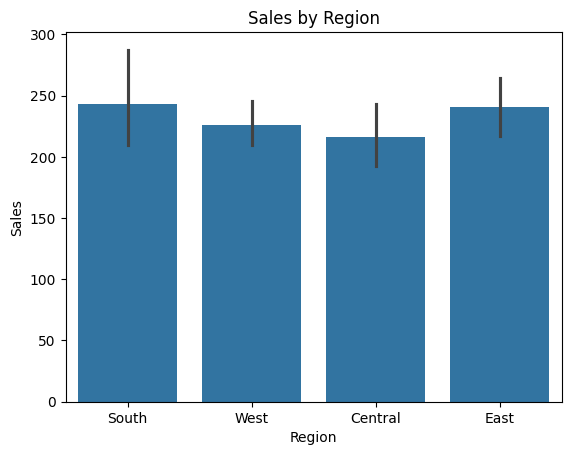

While average sales are relatively uniform across East, Central, and West regions, the South region leads in sales volume but also carries a significantly higher standard deviation.



In [7]:
sns.barplot(x="Region", y="Sales", data=sales_df)
plt.title("Sales by Region")
plt.show()
print("While average sales are relatively uniform across East, Central, and West regions, the South region leads in sales volume but also carries a significantly higher standard deviation.\n")

**Observation:** Average sales are relatively uniform across regions, but the South shows the highest volume with notable variability.

## 7. Top 10 States by Sales

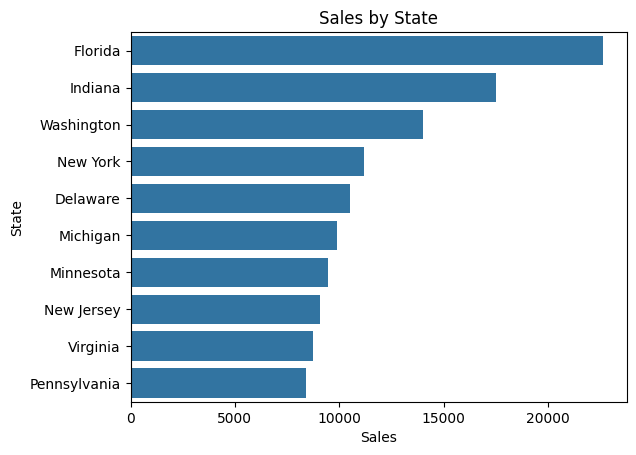

The state with the highest sales is 'Florida', followed by 'Indiana'.



In [8]:
sns.barplot(x="Sales", y="State", data=sales_df.sort_values(by="Sales", ascending=False).head(10))
plt.title("Sales by State")
plt.show()
print("The state with the highest sales is 'Florida', followed by 'Indiana'.\n")

**Observation:** Florida leads in sales among all states, followed by Indiana.

## 8. Top 10 Cities by Sales

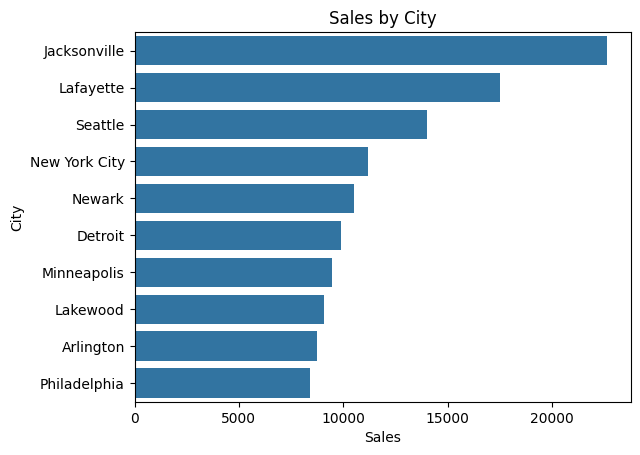

The city with the highest sales is 'Jacksonville', followed by 'Lafayette'.



In [9]:
sns.barplot(x="Sales", y="City", data=sales_df.sort_values(by="Sales", ascending=False).head(10))
plt.title("Sales by City")
plt.show()
print("The city with the highest sales is 'Jacksonville', followed by 'Lafayette'.\n")

**Observation:** Jacksonville is the highest-performing city by sales, followed by Lafayette.

## 9. Sales by Customer Segment

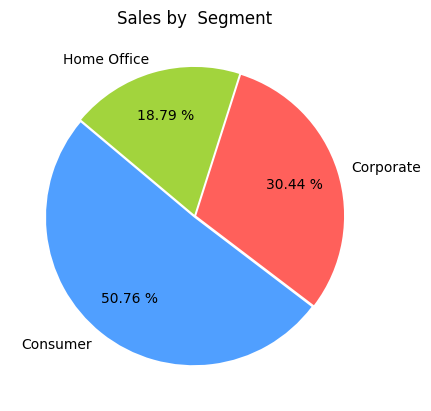

The Consumer segment dominates with over half of all sales (50.8%), followed by Corporate (30.4%) and Home Office (18.8%).



In [10]:
segment_sales = sales_df.groupby('Segment')['Sales'].sum()
plt.pie(segment_sales, labels=segment_sales.index, startangle=140, autopct="%.2f %%", colors=["#509fff", "#ff605b", "#a2d43d"], pctdistance=0.7, explode=[0.01,0.01,0.01])
plt.title("Sales by  Segment")
plt.show()
print("The Consumer segment dominates with over half of all sales (50.8%), followed by Corporate (30.4%) and Home Office (18.8%).\n")

**Observation:** The Consumer segment dominates with over half of total sales (50.8%), followed by Corporate (30.4%) and Home Office (18.8%).

## 10. Shipping Mode Analysis

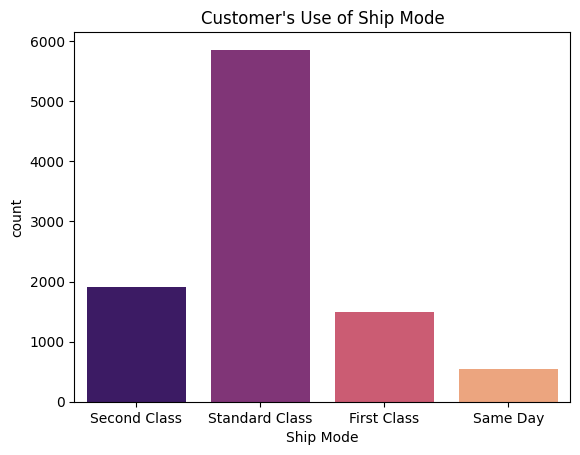

Most customers use the 'Standard Class' ship mode, while 'Same Day' ship mode is used the least by customers.



In [11]:
sns.countplot(x="Ship Mode", data=sales_df, hue="Ship Mode", palette="magma")
plt.title("Customer's Use of Ship Mode")
plt.show()
print("Most customers use the 'Standard Class' ship mode, while 'Same Day' ship mode is used the least by customers.\n")

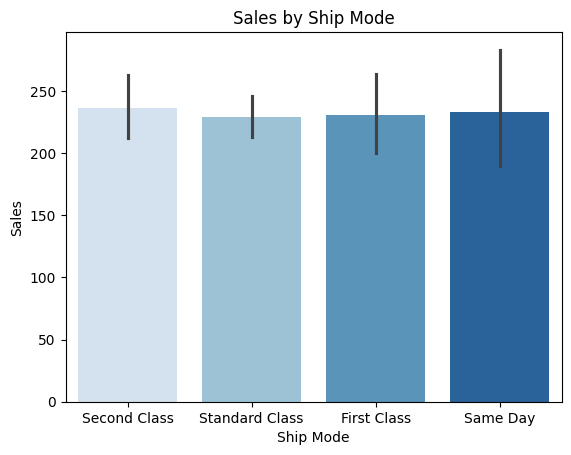

Average sales are highly consistent across all ship modes, with 'Same Day' showing the highest average and variability, while 'Standard Class' is the lowest and most consistent.



In [12]:
sns.barplot(x="Ship Mode", y="Sales", hue="Ship Mode", data=sales_df, palette="Blues")
plt.title("Sales by Ship Mode")
plt.show()
print("Average sales are highly consistent across all ship modes, with 'Same Day' showing the highest average and variability, while 'Standard Class' is the lowest and most consistent.\n")

**Observation:** Standard Class is the most used shipping mode. Despite Same Day delivery showing the highest average sale value, it is the least used — suggesting an opportunity to promote faster shipping options.

## 11. Top 10 Customers by Sales

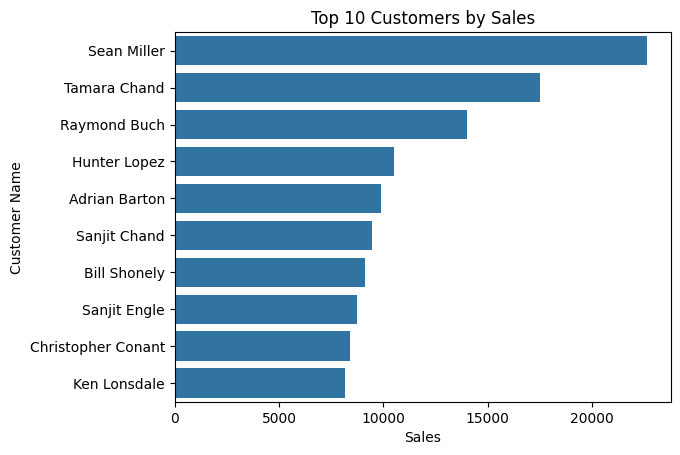

The top customer by sales is 'Sean Miller', followed by 'Tamara Chand'.



In [13]:
sns.barplot(x="Sales", y="Customer Name", data=sales_df.loc[sales_df["Customer Name"].duplicated()].sort_values(by="Sales", ascending=False).head(10))
plt.title("Top 10 Customers by Sales")
plt.show()
print("The top customer by sales is 'Sean Miller', followed by 'Tamara Chand'.\n")

**Observation:** Sean Miller is the top customer by sales, followed by Tamara Chand.

## 12. Monthly Sales Trend

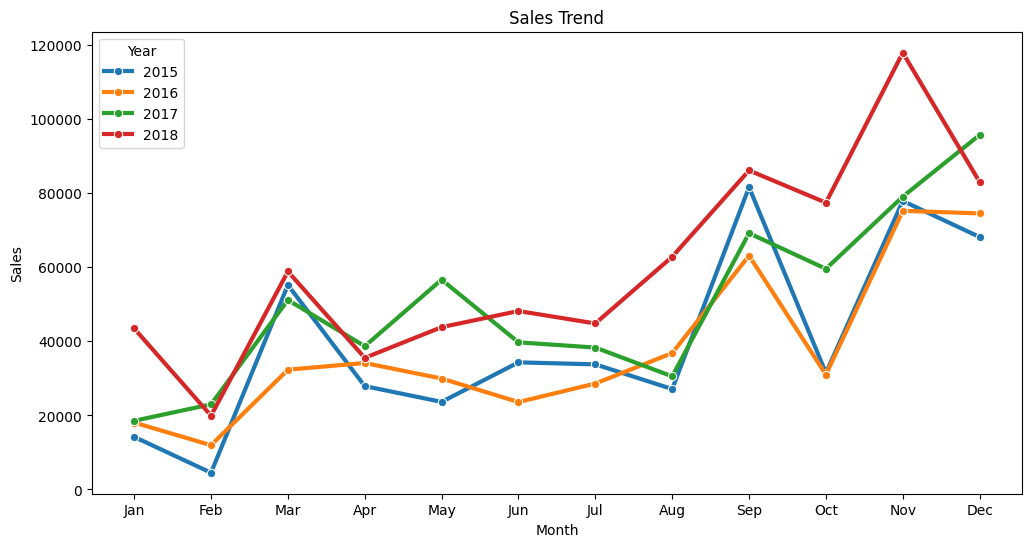

Sales exhibit clear seasonality with sharp peaks every September and November across all years, followed by consistent drops in February and October.



In [14]:
monthly_sales = (sales_df.groupby([sales_df['Order Date'].dt.year.rename("Year"), sales_df['Order Date'].dt.month.rename("Month")])['Sales'].sum().reset_index())
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker='o', palette='tab10', linewidth=3)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title("Sales Trend")
plt.show()
print("Sales exhibit clear seasonality with sharp peaks every September and November across all years, followed by consistent drops in February and October.\n")

**Observation:** Sales peak consistently every September and November across all years, likely tied to back-to-school and holiday seasons. February and October show consistent dips.

## 13. Shipping Duration Distribution

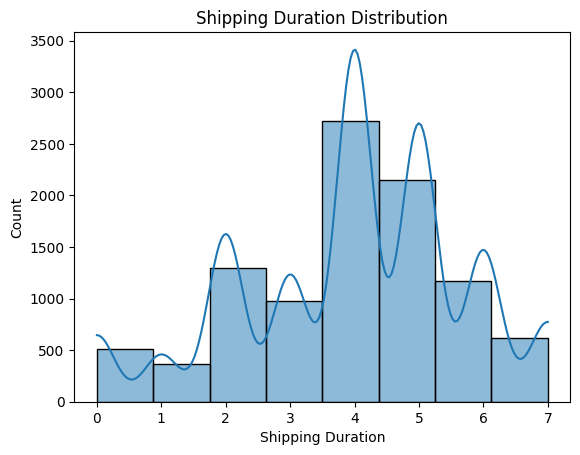

Average shipping duration: 4.0 days




In [15]:
sns.histplot(sales_df["Shipping Duration"], bins=8, kde=True)
plt.title("Shipping Duration Distribution")
plt.show()
print(f"Average shipping duration: {sales_df['Shipping Duration'].mean():.1f} days\n\n")

**Observation:** Most orders are shipped within 3-5 days, with a fairly consistent distribution across the dataset.

## 14. Summary

In [16]:
#Summary
print("Summary:\nThis analysis shows a business driven primarily by the Consumer segment (over half of revenue) and the Technology category, with Copiers and Machines as top sub-categories. Sales are concentrated in a few key markets — led by Florida and Jacksonville — with the South region showing the highest volume but also the most volatility. Customers favor Standard Class shipping despite Same Day delivery yielding higher average sales, pointing to a possible opportunity to promote faster options. Sales also peak consistently every September and November, useful for inventory and marketing planning.")

Summary:
This analysis shows a business driven primarily by the Consumer segment (over half of revenue) and the Technology category, with Copiers and Machines as top sub-categories. Sales are concentrated in a few key markets — led by Florida and Jacksonville — with the South region showing the highest volume but also the most volatility. Customers favor Standard Class shipping despite Same Day delivery yielding higher average sales, pointing to a possible opportunity to promote faster options. Sales also peak consistently every September and November, useful for inventory and marketing planning.


## Conclusion

- **Top performers:** Technology category and Copiers/Machines sub-category drive the highest sales
- **Key markets:** Florida and Jacksonville are the strongest geographic markets
- **Customer base:** Consumer segment accounts for the majority of revenue
- **Shipping:** Standard Class dominates usage, but Same Day shows higher average order value
- **Seasonality:** September and November are peak months — ideal for inventory buildup and marketing campaigns
- **Opportunity:** Promoting faster shipping options and targeting Corporate/Home Office segments could diversify and grow revenue